# Data Mining Homework 1: Emotion Dataset

This notebook studies the Hugging Face `emotion` dataset with two unsupervised strategies:

1. **Clustering** with TF-IDF features and K-Means.
2. **Topic discovery** with TF-IDF features and Non-negative Matrix Factorization (NMF).

The training split is used to estimate the models. The labels are only used to measure agreement with the discovered structure, not as ground truth for the unsupervised models.

In [1]:
# If you are missing packages, uncomment the next line in Jupyter:
# %pip install datasets scikit-learn pandas matplotlib

import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, accuracy_score, normalized_mutual_info_score

np.random.seed(42)
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 13, "axes.labelsize": 11})

c:\Users\Alex\miniconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the data

The dataset contains three splits: `train`, `validation`, and `test`.
We keep the text preprocessing intentionally light so we do not destroy emotion-bearing words.

In [2]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


try:
    emotion = load_dataset("emotion")
except Exception as exc:
    raise RuntimeError(
        "Could not load the Hugging Face 'emotion' dataset. Check that the machine has internet access."
    ) from exc

label_names = emotion["train"].features["label"].names
n_labels = len(label_names)

splits = {}
for split_name in emotion.keys():
    texts = [clean_text(text) for text in emotion[split_name]["text"]]
    labels = np.array(emotion[split_name]["label"], dtype=int)
    splits[split_name] = {"texts": texts, "labels": labels}
    counts = Counter(labels)
    readable = {label_names[i]: counts[i] for i in range(n_labels)}
    print(f"{split_name:>10}  n={len(texts):>5}  {readable}")

label_names

     train  n=16000  {'sadness': 4666, 'joy': 5362, 'love': 1304, 'anger': 2159, 'fear': 1937, 'surprise': 572}
validation  n= 2000  {'sadness': 550, 'joy': 704, 'love': 178, 'anger': 275, 'fear': 212, 'surprise': 81}


      test  n= 2000  {'sadness': 581, 'joy': 695, 'love': 159, 'anger': 275, 'fear': 224, 'surprise': 66}


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

## 2. TF-IDF representation

We fit the vectorizer on the training texts only, then reuse it for validation and test.

In [3]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    max_features=12000,
)

X_train = vectorizer.fit_transform(splits["train"]["texts"])
X_val = vectorizer.transform(splits["validation"]["texts"])
X_test = vectorizer.transform(splits["test"]["texts"])
feature_names = np.array(vectorizer.get_feature_names_out())

print("Train matrix:", X_train.shape)
print("Validation matrix:", X_val.shape)
print("Test matrix:", X_test.shape)

Train matrix: (16000, 12000)
Validation matrix: (2000, 12000)
Test matrix: (2000, 12000)


## 3. Shared evaluation helpers

Because cluster and topic IDs are arbitrary, we learn a best mapping from discovered groups to labels using the training split, then evaluate the same mapping on the other splits.

In [4]:
def contingency_matrix(true_labels: np.ndarray, predicted_labels: np.ndarray, n_true: int, n_pred: int) -> np.ndarray:
    matrix = np.zeros((n_true, n_pred), dtype=int)
    for true_label, pred_label in zip(true_labels, predicted_labels):
        matrix[true_label, pred_label] += 1
    return matrix


def best_label_mapping(true_labels: np.ndarray, predicted_labels: np.ndarray, n_true: int) -> tuple[dict[int, int], np.ndarray]:
    matrix = contingency_matrix(true_labels, predicted_labels, n_true=n_true, n_pred=int(predicted_labels.max()) + 1)
    row_ind, col_ind = linear_sum_assignment(matrix.max() - matrix)
    mapping = {int(col): int(row) for row, col in zip(row_ind, col_ind)}
    return mapping, matrix


def apply_mapping(predicted_labels: np.ndarray, mapping: dict[int, int]) -> np.ndarray:
    return np.array([mapping[int(label)] for label in predicted_labels], dtype=int)


def purity_score(true_labels: np.ndarray, predicted_labels: np.ndarray) -> float:
    total = 0
    for cluster_id in np.unique(predicted_labels):
        mask = predicted_labels == cluster_id
        majority = Counter(true_labels[mask]).most_common(1)[0][1]
        total += majority
    return total / len(true_labels)


def evaluate_partition(true_labels: np.ndarray, predicted_labels: np.ndarray, mapped_predictions: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": accuracy_score(true_labels, mapped_predictions),
        "ARI": adjusted_rand_score(true_labels, predicted_labels),
        "NMI": normalized_mutual_info_score(true_labels, predicted_labels),
        "purity": purity_score(true_labels, predicted_labels),
    }


def top_terms_per_component(weights: np.ndarray, terms: np.ndarray, top_n: int = 10) -> list[list[str]]:
    rows = []
    for row in weights:
        top_idx = np.argsort(row)[::-1][:top_n]
        rows.append([str(terms[i]) for i in top_idx])
    return rows


def plot_matrix(matrix: np.ndarray, row_labels: list[str], col_labels: list[str], title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right")
    ax.set_yticklabels(row_labels)
    ax.set_xlabel("Discovered group")
    ax.set_ylabel("True label")
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, int(matrix[i, j]), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()


split_order = ["train", "validation", "test"]

## 4. Clustering with K-Means

We use one cluster per emotion label. This does not force the algorithm to rediscover the same classes, but it gives a direct way to compare structure and label agreement.

,split,accuracy,ARI,NMI,purity
0,train,0.264313,0.002788,0.003234,0.33725
1,validation,0.261500,0.003466,0.008372,0.35550
2,test,0.263000,0.006361,0.008577,0.34750


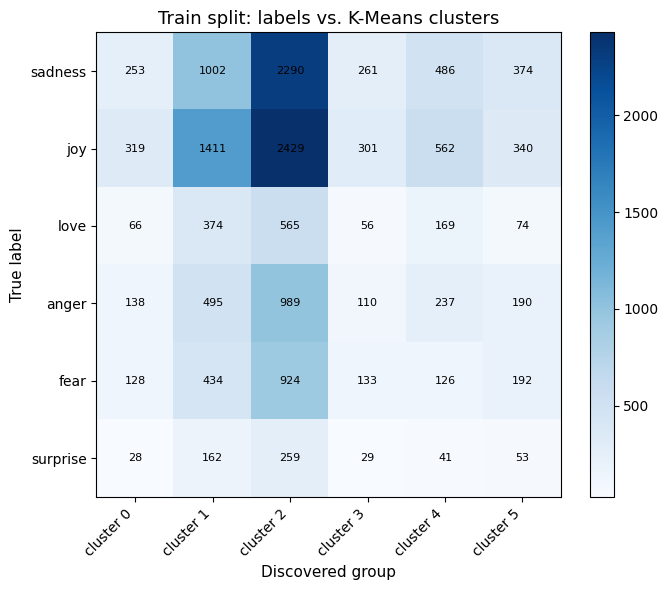

In [5]:
kmeans = KMeans(n_clusters=n_labels, n_init=20, random_state=42)

cluster_predictions = {
    "train": kmeans.fit_predict(X_train),
    "validation": kmeans.predict(X_val),
    "test": kmeans.predict(X_test),
}

cluster_mapping, cluster_train_matrix = best_label_mapping(splits["train"]["labels"], cluster_predictions["train"], n_true=n_labels)

cluster_rows = []
for split_name in split_order:
    true_labels = splits[split_name]["labels"]
    predicted = cluster_predictions[split_name]
    mapped = apply_mapping(predicted, cluster_mapping)
    cluster_rows.append({"split": split_name, **evaluate_partition(true_labels, predicted, mapped)})

cluster_report = pd.DataFrame(cluster_rows)
display(cluster_report)

plot_matrix(cluster_train_matrix, label_names, [f"cluster {i}" for i in range(n_labels)], "Train split: labels vs. K-Means clusters")

In [6]:
cluster_terms = top_terms_per_component(kmeans.cluster_centers_, feature_names, top_n=10)
cluster_summary = pd.DataFrame(
    {
        "cluster": list(range(n_labels)),
        "mapped_label": [label_names[cluster_mapping[c]] for c in range(n_labels)],
        "top_terms": [", ".join(terms) for terms in cluster_terms],
    }
)
display(cluster_summary)

,cluster,mapped_label,top_terms
0,0,anger,"im, im feeling, feeling, and, to, today, the, ..."
1,1,joy,"the, of, and, to, that, in, feel, my, feeling,..."
2,2,sadness,"feel, to, and, so, that, my, it, feel so, abou..."
3,3,surprise,"am, am feeling, feeling, been feeling, and, be..."
4,4,love,"feel like, like, feel, to, and, the, like im, ..."
5,5,fear,"was, was feeling, feeling, and, to, the, that,..."


## 5. Topic discovery with NMF

NMF usually produces cleaner topics than LDA on short texts because it works directly on the TF-IDF representation. We again fit on the training split only.

,split,accuracy,ARI,NMI,purity
0,train,0.260813,0.002467,0.004404,0.349813
1,validation,0.255500,0.002625,0.009436,0.361500
2,test,0.261500,0.000820,0.007349,0.351500


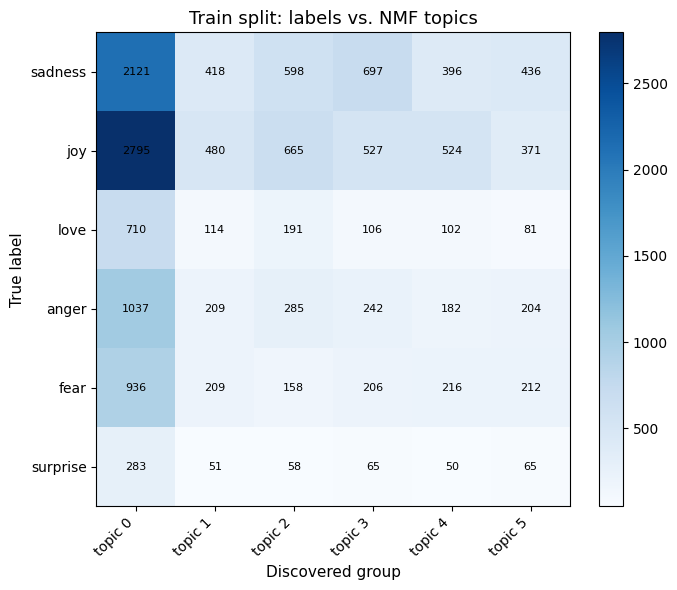

In [7]:
nmf = NMF(n_components=n_labels, init="nndsvda", random_state=42, max_iter=500)

topic_weights = {
    "train": nmf.fit_transform(X_train),
    "validation": nmf.transform(X_val),
    "test": nmf.transform(X_test),
}
topic_predictions = {split_name: weights.argmax(axis=1) for split_name, weights in topic_weights.items()}

topic_mapping, topic_train_matrix = best_label_mapping(splits["train"]["labels"], topic_predictions["train"], n_true=n_labels)

topic_rows = []
for split_name in split_order:
    true_labels = splits[split_name]["labels"]
    predicted = topic_predictions[split_name]
    mapped = apply_mapping(predicted, topic_mapping)
    topic_rows.append({"split": split_name, **evaluate_partition(true_labels, predicted, mapped)})

topic_report = pd.DataFrame(topic_rows)
display(topic_report)

plot_matrix(topic_train_matrix, label_names, [f"topic {i}" for i in range(n_labels)], "Train split: labels vs. NMF topics")

In [8]:
topic_terms = top_terms_per_component(nmf.components_, feature_names, top_n=10)
topic_summary = pd.DataFrame(
    {
        "topic": list(range(n_labels)),
        "mapped_label": [label_names[topic_mapping[t]] for t in range(n_labels)],
        "top_terms": [", ".join(terms) for terms in topic_terms],
    }
)
display(topic_summary)

,topic,mapped_label,top_terms
0,0,joy,"the, to, and, of, that, feel, my, in, it, is"
1,1,anger,"im, im feeling, feeling, today, little, feelin..."
2,2,love,"like, feel like, feel, like im, like am, being..."
3,3,sadness,"so, feel so, feel, feeling so, just, just feel..."
4,4,fear,"am, am feeling, feeling, very, feeling very, a..."
5,5,surprise,"was, was feeling, feeling, and, had, pretty, i..."


## 6. Observed Results

| Method | Split | Accuracy | ARI | NMI | Purity |
| --- | --- | ---: | ---: | ---: | ---: |
| K-Means | Train | 0.2643 | 0.0028 | 0.0032 | 0.3373 |
| K-Means | Validation | 0.2615 | 0.0035 | 0.0084 | 0.3555 |
| K-Means | Test | 0.2630 | 0.0064 | 0.0086 | 0.3475 |
| NMF | Train | 0.2608 | 0.0025 | 0.0044 | 0.3498 |
| NMF | Validation | 0.2555 | 0.0026 | 0.0094 | 0.3615 |
| NMF | Test | 0.2615 | 0.0008 | 0.0073 | 0.3515 |

These values show that both methods recover only a weak alignment with the emotion labels, even though the topic words are still semantically plausible.

## 7. Conclusions

The results are consistent across the three splits, and the main conclusion is that this is a **hard unsupervised problem** for short texts.

- K-Means reached only about **0.26 accuracy** on train, validation, and test, with **purity around 0.34 to 0.36** and **ARI/NMI values close to zero**. That means the algorithm found some coarse grouping, but the grouping is only weakly aligned with the emotion labels.
- NMF behaved in a very similar way: accuracy stayed around **0.25 to 0.26**, purity around **0.35**, and ARI/NMI again remained very small. The topic model is therefore more interpretable than K-Means, but not substantially better at recovering the labeled emotions.
- The strongest discovered components are dominated by generic writing patterns such as `im`, `feeling`, `was`, `am`, `like`, `feel`, and `today`. This shows that the models mainly capture surface phrasing and sentence templates, not pure emotional content.
- One cluster/topic tends to absorb a large share of the data, which suggests the representation is still dominated by common vocabulary. A richer representation, such as embeddings or sentence-transformer features, would likely separate the emotions better.
- Even with weak label agreement, the output is still useful: it shows that `emotion` contains some separable structure, but the labels are not perfectly mirrored by the unsupervised geometry of TF-IDF space.

If we had more time, the most meaningful next step would be to compare TF-IDF with embeddings, then check whether the discovered groups become more emotion-specific. For the current homework, though, the important result is honest: the two unsupervised methods reveal a noisy, partially structured space rather than a clean recovery of the label set.